# Focused Logistic Regression Baseline — 6 months

Здесь делаем именно логрегу для классификации toxic maker fills.

Идея:

- строим фичи из liquidation clusters + L1 BBO microstructure;
- label: `bad_trade = 1[pnl_horizon < 0]`;
- обучаем weighted `LogisticRegression`;
- фильтруем сделки с наибольшей predicted probability of bad fill;
- threshold выбираем на train по максимальному `Score = PnL_kept - PnL_all` при turnover constraint.

Ноутбук локальный, пока не пушим.


## New data split

Detected public data range: `2025-11-01 → 2026-04-28` (`179` covered days).

Since the new `description.md` still contains the old 3-month split, this notebook uses a pragmatic 6-month split:

- train: `2025-11-01 → 2026-03-31`;
- validation: `2026-04-01 → 2026-04-28`.

Default executed mode uses representative sampled days across the new range. Full mode: set `RUN_FULL_6M = True` and `SAMPLE_MOD = None` or a larger sampled value.


In [1]:
from pathlib import Path
from datetime import datetime, timezone, timedelta
import warnings

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 140)
pd.set_option('display.max_rows', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.6g}')

DATA = Path('liquidation_task 2/data')
DAY_US = 86_400 * 1_000_000
HORIZONS = [30, 120, 300]
WINDOWS = [1, 5, 30, 120]
SYMBOLS = ['btc', 'eth']

# Fast local mode. Full run: set RUN_FULL_3M=True and SAMPLE_MOD=None.
RUN_FULL_6M = True
SAMPLE_MOD = 1_000
SAMPLE_SCALE = 1 if SAMPLE_MOD is None else SAMPLE_MOD

TRAIN_DAYS_FAST = ['2025-11-03', '2025-11-20', '2025-12-01', '2025-12-14', '2026-01-13', '2026-01-31', '2026-02-06', '2026-02-21', '2026-03-10', '2026-03-25']
VAL_DAYS_FAST = ['2026-04-02', '2026-04-10', '2026-04-20', '2026-04-28']

def days_between(start, end_excl):
    cur = datetime.fromisoformat(start).replace(tzinfo=timezone.utc)
    end = datetime.fromisoformat(end_excl).replace(tzinfo=timezone.utc)
    out = []
    while cur < end:
        out.append(cur.date().isoformat())
        cur += timedelta(days=1)
    return out

TRAIN_DAYS = days_between('2025-11-01', '2026-04-01') if RUN_FULL_6M else TRAIN_DAYS_FAST
VAL_DAYS = days_between('2026-04-01', '2026-04-29') if RUN_FULL_6M else VAL_DAYS_FAST

def dt_us(day):
    return int(datetime.fromisoformat(day).replace(tzinfo=timezone.utc).timestamp() * 1_000_000)

def data_path(kind, symbol):
    if kind == 'trades':
        return DATA / 'binance_trades' / f'perp_{symbol}usdt.parquet'
    if kind == 'bbo':
        return DATA / 'binance_booktickers' / f'perp_{symbol}usdt.parquet'
    if kind == 'bin_liq':
        return DATA / 'binance_liquidations' / f'perp_{symbol}usdt.parquet'
    if kind == 'bybit_liq':
        return DATA / 'bybit_liquidations' / f'{symbol}usdt.parquet'
    raise ValueError(kind)

print('RUN_FULL_6M:', RUN_FULL_6M, 'SAMPLE_MOD:', SAMPLE_MOD)
print('TRAIN_DAYS:', TRAIN_DAYS)
print('VAL_DAYS:', VAL_DAYS)

RUN_FULL_6M: True SAMPLE_MOD: 1000
TRAIN_DAYS: ['2025-11-01', '2025-11-02', '2025-11-03', '2025-11-04', '2025-11-05', '2025-11-06', '2025-11-07', '2025-11-08', '2025-11-09', '2025-11-10', '2025-11-11', '2025-11-12', '2025-11-13', '2025-11-14', '2025-11-15', '2025-11-16', '2025-11-17', '2025-11-18', '2025-11-19', '2025-11-20', '2025-11-21', '2025-11-22', '2025-11-23', '2025-11-24', '2025-11-25', '2025-11-26', '2025-11-27', '2025-11-28', '2025-11-29', '2025-11-30', '2025-12-01', '2025-12-02', '2025-12-03', '2025-12-04', '2025-12-05', '2025-12-06', '2025-12-07', '2025-12-08', '2025-12-09', '2025-12-10', '2025-12-11', '2025-12-12', '2025-12-13', '2025-12-14', '2025-12-15', '2025-12-16', '2025-12-17', '2025-12-18', '2025-12-19', '2025-12-20', '2025-12-21', '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25', '2025-12-26', '2025-12-27', '2025-12-28', '2025-12-29', '2025-12-30', '2025-12-31', '2026-01-01', '2026-01-02', '2026-01-03', '2026-01-04', '2026-01-05', '2026-01-06', '2026-01-07', 

In [2]:
def load_bbo_window(symbol, start_us, end_us):
    margin_us = 310 * 1_000_000
    return (
        pl.scan_parquet(data_path('bbo', symbol))
        .filter((pl.col('timestamp') >= start_us - margin_us) & (pl.col('timestamp') <= end_us + margin_us))
        .select([
            pl.col('timestamp').alias('bbo_ts'),
            pl.col('bid_price'), pl.col('ask_price'), pl.col('bid_amount'), pl.col('ask_amount'),
            ((pl.col('bid_price') + pl.col('ask_price')) / 2).alias('mid'),
            ((pl.col('ask_price') - pl.col('bid_price')) / ((pl.col('ask_price') + pl.col('bid_price')) / 2) * 10_000).alias('spread_bps'),
            ((pl.col('bid_amount') - pl.col('ask_amount')) / (pl.col('bid_amount') + pl.col('ask_amount'))).alias('imbalance'),
            ((pl.col('ask_price') * pl.col('bid_amount') + pl.col('bid_price') * pl.col('ask_amount')) / (pl.col('bid_amount') + pl.col('ask_amount'))).alias('microprice'),
        ])
        .collect()
        .sort('bbo_ts')
        .with_columns(((pl.col('microprice') - pl.col('mid')) / pl.col('mid') * 10_000).alias('microprice_minus_mid_bps'))
    )

def load_liq_second_features(symbol, start_us, end_us):
    start_hist = start_us - 130 * 1_000_000
    end_hist = end_us + 1_000_000
    frames = []
    for source, kind, delay_us in [('bin', 'bin_liq', 0), ('byb', 'bybit_liq', 200_000)]:
        cols = [f'{source}_buy_notional', f'{source}_sell_notional', f'{source}_buy_count', f'{source}_sell_count']
        frame = (
            pl.scan_parquet(data_path(kind, symbol))
            .filter((pl.col('timestamp') + delay_us >= start_hist) & (pl.col('timestamp') + delay_us <= end_hist))
            .with_columns([
                ((pl.col('timestamp') + delay_us) // 1_000_000).cast(pl.Int64).alias('sec'),
                (pl.col('price') * pl.col('amount')).alias('notional'),
            ])
            .group_by(['sec', 'side'])
            .agg([pl.len().alias('count'), pl.sum('notional').alias('notional')])
            .with_columns([
                pl.when(pl.col('side') == 'buy').then(pl.col('notional')).otherwise(0).alias(cols[0]),
                pl.when(pl.col('side') == 'sell').then(pl.col('notional')).otherwise(0).alias(cols[1]),
                pl.when(pl.col('side') == 'buy').then(pl.col('count')).otherwise(0).alias(cols[2]),
                pl.when(pl.col('side') == 'sell').then(pl.col('count')).otherwise(0).alias(cols[3]),
            ])
            .group_by('sec')
            .agg([pl.sum(x).alias(x) for x in cols])
            .collect()
        )
        frames.append(frame)

    grid = pl.DataFrame({'sec': pl.arange(start_hist // 1_000_000, end_hist // 1_000_000 + 1, eager=True)})
    out = grid
    for frame in frames:
        out = out.join(frame, on='sec', how='left')
    out = out.fill_null(0).sort('sec')
    base_cols = [x for x in out.columns if x != 'sec']
    for w in WINDOWS:
        out = out.with_columns([pl.col(x).rolling_sum(window_size=w, min_samples=1).alias(f'{x}_{w}s') for x in base_cols])
        out = out.with_columns([
            (pl.col(f'bin_buy_notional_{w}s') + pl.col(f'byb_buy_notional_{w}s')).alias(f'all_buy_liq_notional_{w}s'),
            (pl.col(f'bin_sell_notional_{w}s') + pl.col(f'byb_sell_notional_{w}s')).alias(f'all_sell_liq_notional_{w}s'),
            (pl.col(f'bin_buy_count_{w}s') + pl.col(f'byb_buy_count_{w}s')).alias(f'all_buy_liq_count_{w}s'),
            (pl.col(f'bin_sell_count_{w}s') + pl.col(f'byb_sell_count_{w}s')).alias(f'all_sell_liq_count_{w}s'),
        ])
    return out

def load_trade_day(symbol, day, sample_mod=SAMPLE_MOD):
    start_us = dt_us(day)
    end_us = start_us + DAY_US
    lf = (
        pl.scan_parquet(data_path('trades', symbol))
        .filter((pl.col('timestamp') >= start_us) & (pl.col('timestamp') < end_us))
        .select(['timestamp', 'side', 'price', 'amount'])
    )
    if sample_mod is not None:
        lf = (
            lf.with_columns(pl.struct(['timestamp', 'side', 'price', 'amount']).hash(seed=42).alias('_hash'))
            .filter((pl.col('_hash') % sample_mod) == 0)
            .drop('_hash')
        )
    return lf.collect().sort('timestamp')

In [3]:
def build_features_for_day(symbol, day, sample_mod=SAMPLE_MOD):
    start_us = dt_us(day)
    end_us = start_us + DAY_US
    trades = load_trade_day(symbol, day, sample_mod)
    if trades.height == 0:
        return trades
    bbo = load_bbo_window(symbol, start_us, end_us)
    liq = load_liq_second_features(symbol, start_us, end_us)

    df = (
        trades
        .with_columns([
            pl.lit(symbol).alias('symbol'),
            pl.lit(day).alias('day'),
            (pl.col('price') * pl.col('amount')).alias('notional'),
            pl.min_horizontal(pl.col('price') * pl.col('amount'), pl.lit(100_000.0)).alias('w'),
            (pl.col('timestamp') // 1_000_000).cast(pl.Int64).alias('sec'),
            pl.when(pl.col('side') == 'buy').then(1.0).otherwise(-1.0).alias('s'),
        ])
        .join_asof(bbo, left_on='timestamp', right_on='bbo_ts', strategy='backward')
        .with_columns([
            ((pl.col('timestamp') - pl.col('bbo_ts')) / 1_000).alias('bbo_lag_ms'),
            ((pl.col('microprice') - pl.col('mid')) / pl.col('mid') * 10_000).alias('microprice_minus_mid_bps'),
        ])
    )

    for past_s in [1, 5, 30]:
        df = df.with_columns((pl.col('timestamp') - past_s * 1_000_000).alias(f'target_past_{past_s}s'))
        past_mid = bbo.select([
            pl.col('bbo_ts').alias(f'bbo_past_ts_{past_s}s'),
            pl.col('mid').alias(f'mid_past_{past_s}s'),
        ])
        df = df.join_asof(past_mid, left_on=f'target_past_{past_s}s', right_on=f'bbo_past_ts_{past_s}s', strategy='backward')
        df = df.with_columns([
            ((pl.col('mid') - pl.col(f'mid_past_{past_s}s')) / pl.col(f'mid_past_{past_s}s') * 10_000).alias(f'ret_{past_s}s_bps'),
            ((pl.col('mid') - pl.col(f'mid_past_{past_s}s')) / pl.col(f'mid_past_{past_s}s') * 10_000 * pl.col('s')).alias(f'side_adj_ret_{past_s}s_bps'),
        ])

    for h in HORIZONS:
        df = df.with_columns((pl.col('timestamp') + h * 1_000_000).alias(f'target_{h}s'))
        future_mid = bbo.select([
            pl.col('bbo_ts').alias(f'bbo_future_ts_{h}s'),
            pl.col('mid').alias(f'mid_{h}s'),
        ])
        df = df.join_asof(future_mid, left_on=f'target_{h}s', right_on=f'bbo_future_ts_{h}s', strategy='backward')
        df = df.with_columns([
            ((pl.col(f'target_{h}s') - pl.col(f'bbo_future_ts_{h}s')) / 1_000).alias(f'bbo_future_lag_{h}s_ms'),
            (-pl.col('s') * (pl.col(f'mid_{h}s') - pl.col('price')) / pl.col('price') * 10_000 + 0.5).alias(f'pnl_{h}s_bps'),
        ])

    df = df.join(liq, on='sec', how='left').fill_null(0)
    exprs = [
        (pl.col('imbalance') * pl.col('s')).alias('side_adj_imbalance'),
        (pl.col('microprice_minus_mid_bps') * pl.col('s')).alias('side_adj_microprice_bps'),
        (pl.col('bbo_lag_ms') > 250).cast(pl.Int8).alias('stale_bbo_flag'),
    ]
    for w in WINDOWS:
        buy = pl.col(f'all_buy_liq_notional_{w}s')
        sell = pl.col(f'all_sell_liq_notional_{w}s')
        exprs += [
            pl.when(pl.col('side') == 'buy').then(buy).otherwise(sell).alias(f'same_liq_notional_{w}s'),
            pl.when(pl.col('side') == 'buy').then(sell).otherwise(buy).alias(f'opp_liq_notional_{w}s'),
            ((buy - sell) / (buy + sell + 1.0) * pl.col('s')).alias(f'side_adj_liq_imbalance_{w}s'),
            (buy + sell).alias(f'total_liq_notional_{w}s'),
        ]
    return df.with_columns(exprs)

def build_dataset(days):
    parts = []
    for day in days:
        for symbol in SYMBOLS:
            print(f'build {symbol} {day}')
            part = build_features_for_day(symbol, day)
            print('  rows:', part.height)
            parts.append(part)
    return pl.concat(parts, how='diagonal_relaxed')

train_pl = build_dataset(TRAIN_DAYS)
val_pl = build_dataset(VAL_DAYS)
print(train_pl.shape, val_pl.shape)

build btc 2025-11-01


  rows: 1380
build eth 2025-11-01


  rows: 2459
build btc 2025-11-02
  rows: 1977
build eth 2025-11-02


  rows: 3130
build btc 2025-11-03


  rows: 5674
build eth 2025-11-03


...

  rows: 1196
build btc 2026-04-26
  rows: 1915
build eth 2026-04-26


  rows: 2561
build btc 2026-04-27


  rows: 3771
build eth 2026-04-27


  rows: 5031
build btc 2026-04-28
  rows: 2627
build eth 2026-04-28


  rows: 3632
(1928809, 126) (246500, 126)


In [4]:
FEATURES = []
for w in WINDOWS:
    FEATURES += [
        f'same_liq_notional_{w}s', f'opp_liq_notional_{w}s', f'total_liq_notional_{w}s', f'side_adj_liq_imbalance_{w}s',
        f'byb_buy_count_{w}s', f'byb_sell_count_{w}s', f'byb_buy_notional_{w}s', f'byb_sell_notional_{w}s',
        f'bin_buy_notional_{w}s', f'bin_sell_notional_{w}s',
    ]
FEATURES += [
    'spread_bps', 'imbalance', 'side_adj_imbalance',
    'microprice_minus_mid_bps', 'side_adj_microprice_bps',
    'ret_1s_bps', 'ret_5s_bps', 'ret_30s_bps',
    'side_adj_ret_1s_bps', 'side_adj_ret_5s_bps', 'side_adj_ret_30s_bps',
    'bbo_lag_ms', 'stale_bbo_flag', 'notional',
    'symbol_btc', 'symbol_eth', 'side_buy', 'side_sell',
]

FLOW_COLS = [x for x in FEATURES if ('notional' in x or '_count_' in x)]

def to_pdf(df, horizon):
    base_cols = ['symbol', 'side', 'day', 'timestamp', 'w', f'pnl_{horizon}s_bps']
    pdf = df.select([x for x in base_cols + [f for f in FEATURES if f in df.columns] if x in df.columns]).to_pandas()
    pdf['symbol_btc'] = (pdf['symbol'] == 'btc').astype(float)
    pdf['symbol_eth'] = (pdf['symbol'] == 'eth').astype(float)
    pdf['side_buy'] = (pdf['side'] == 'buy').astype(float)
    pdf['side_sell'] = (pdf['side'] == 'sell').astype(float)
    for col in FEATURES:
        if col not in pdf.columns:
            pdf[col] = 0.0
        pdf[col] = pdf[col].replace([np.inf, -np.inf], np.nan).fillna(0.0)
        if col in FLOW_COLS:
            pdf[col] = np.log1p(np.clip(pdf[col], 0, None))
    pdf[f'bad_{horizon}s'] = (pdf[f'pnl_{horizon}s_bps'] < 0).astype(int)
    return pdf

def weighted_mean(x, w):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    ok = np.isfinite(x) & np.isfinite(w) & (w > 0)
    return np.nan if ok.sum() == 0 else float(np.sum(x[ok] * w[ok]) / np.sum(w[ok]))

def metrics(pdf, horizon, filt, sample_scale=SAMPLE_SCALE):
    filt = np.asarray(filt).astype(bool)
    w = pdf['w'].to_numpy(float)
    pnl = pdf[f'pnl_{horizon}s_bps'].to_numpy(float)
    n_days = max(1, pdf['day'].nunique())
    pnl_all = weighted_mean(pnl, w)
    pnl_kept = weighted_mean(pnl[~filt], w[~filt])
    pnl_filtered = weighted_mean(pnl[filt], w[filt])
    kept_turnover = float(w[~filt].sum() * sample_scale / n_days)
    return {
        'rows': len(pdf),
        'filtered_share': float(filt.mean()),
        'PnL_all': pnl_all,
        'PnL_kept': pnl_kept,
        'PnL_filtered': pnl_filtered,
        'Score': pnl_kept - pnl_all,
        'KeptTurnoverPerDay': kept_turnover,
        'turnover_ok': kept_turnover >= 500_000,
    }

def choose_thr(train_pdf, horizon, toxicity_score):
    best = None
    # q=0.50 filters top half; q=0.999 filters only top 0.1% toxic.
    for q in np.linspace(0.50, 0.999, 120):
        thr = float(np.quantile(toxicity_score, q))
        row = {'threshold': thr, 'filter_quantile': q} | metrics(train_pdf, horizon, toxicity_score >= thr)
        if row['turnover_ok'] and (best is None or row['Score'] > best['Score']):
            best = row
    return best

In [5]:
def fit_global_logreg(horizon):
    train = to_pdf(train_pl, horizon)
    val = to_pdf(val_pl, horizon)
    X_train = train[FEATURES].to_numpy(float)
    X_val = val[FEATURES].to_numpy(float)
    y_train = train[f'bad_{horizon}s'].to_numpy(int)
    y_val = val[f'bad_{horizon}s'].to_numpy(int)
    w_train = train['w'].clip(upper=100_000).to_numpy(float)
    w_val = val['w'].clip(upper=100_000).to_numpy(float)

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, C=0.25, class_weight='balanced', solver='lbfgs')
    )
    model.fit(X_train, y_train, logisticregression__sample_weight=w_train)
    p_train = model.predict_proba(X_train)[:, 1]
    p_val = model.predict_proba(X_val)[:, 1]
    thr = choose_thr(train, horizon, p_train)
    train_filter = p_train >= thr['threshold']
    val_filter = p_val >= thr['threshold']

    coef = pd.DataFrame({
        'feature': FEATURES,
        'coef': model.named_steps['logisticregression'].coef_[0],
    })
    coef['abs_coef'] = coef['coef'].abs()
    coef = coef.sort_values('abs_coef', ascending=False)

    rows = [
        {'model': 'global_logreg', 'split': 'train', 'horizon_s': horizon, 'auc_weighted': roc_auc_score(y_train, p_train, sample_weight=w_train), 'threshold': thr['threshold'], 'filter_quantile': thr['filter_quantile']} | metrics(train, horizon, train_filter),
        {'model': 'global_logreg', 'split': 'validation', 'horizon_s': horizon, 'auc_weighted': roc_auc_score(y_val, p_val, sample_weight=w_val), 'threshold': thr['threshold'], 'filter_quantile': thr['filter_quantile']} | metrics(val, horizon, val_filter),
    ]
    return pd.DataFrame(rows), coef, model

def fit_symbol_logregs(horizon):
    all_rows = []
    all_coefs = []
    for symbol in SYMBOLS:
        train = to_pdf(train_pl.filter(pl.col('symbol') == symbol), horizon)
        val = to_pdf(val_pl.filter(pl.col('symbol') == symbol), horizon)
        X_train = train[FEATURES].to_numpy(float)
        X_val = val[FEATURES].to_numpy(float)
        y_train = train[f'bad_{horizon}s'].to_numpy(int)
        y_val = val[f'bad_{horizon}s'].to_numpy(int)
        w_train = train['w'].clip(upper=100_000).to_numpy(float)
        w_val = val['w'].clip(upper=100_000).to_numpy(float)
        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1000, C=0.25, class_weight='balanced', solver='lbfgs')
        )
        model.fit(X_train, y_train, logisticregression__sample_weight=w_train)
        p_train = model.predict_proba(X_train)[:, 1]
        p_val = model.predict_proba(X_val)[:, 1]
        thr = choose_thr(train, horizon, p_train)
        all_rows += [
            {'model': 'symbol_logreg', 'symbol': symbol, 'split': 'train', 'horizon_s': horizon, 'auc_weighted': roc_auc_score(y_train, p_train, sample_weight=w_train), 'threshold': thr['threshold'], 'filter_quantile': thr['filter_quantile']} | metrics(train, horizon, p_train >= thr['threshold']),
            {'model': 'symbol_logreg', 'symbol': symbol, 'split': 'validation', 'horizon_s': horizon, 'auc_weighted': roc_auc_score(y_val, p_val, sample_weight=w_val), 'threshold': thr['threshold'], 'filter_quantile': thr['filter_quantile']} | metrics(val, horizon, p_val >= thr['threshold']),
        ]
        coef = pd.DataFrame({'feature': FEATURES, 'coef': model.named_steps['logisticregression'].coef_[0]})
        coef['abs_coef'] = coef['coef'].abs()
        coef['symbol'] = symbol
        coef['horizon_s'] = horizon
        all_coefs.append(coef.sort_values('abs_coef', ascending=False))
    return pd.DataFrame(all_rows), pd.concat(all_coefs, ignore_index=True)

metric_parts = []
coef_parts = []
models = {}
for h in HORIZONS:
    m, coef, model = fit_global_logreg(h)
    metric_parts.append(m)
    coef['model'] = 'global_logreg'
    coef['horizon_s'] = h
    coef_parts.append(coef)
    models[h] = model
    sm, scoef = fit_symbol_logregs(h)
    metric_parts.append(sm)
    scoef['model'] = 'symbol_logreg'
    coef_parts.append(scoef)

logreg_metrics = pd.concat(metric_parts, ignore_index=True)
logreg_coefs = pd.concat(coef_parts, ignore_index=True)
logreg_metrics.sort_values(['horizon_s', 'split', 'model', 'symbol'], na_position='first')

,model,split,horizon_s,auc_weighted,threshold,filter_quantile,rows,filtered_share,PnL_all,PnL_kept,PnL_filtered,Score,KeptTurnoverPerDay,turnover_ok,symbol
0,global_logreg,train,30,0.541957,0.497582,0.5,1928809,0.5,-0.0368252,0.434425,-0.326408,0.471251,9.42093e+09,True,NaN
2,symbol_logreg,train,30,0.53943,0.504151,0.508387,707513,0.491614,-0.0687297,0.235496,-0.381153,0.304226,6.46158e+09,True,btc
4,symbol_logreg,train,30,0.548617,0.488838,0.5,1221296,0.5,-0.00291246,0.876523,-0.331712,0.879436,3.26515e+09,True,eth
1,global_logreg,validation,30,0.553069,0.497582,0.5,246500,0.464535,-0.109844,0.375033,-0.388917,0.484878,6.56638e+09,True,NaN
3,symbol_logreg,validation,30,0.54199,0.504151,0.508387,97489,0.44244,-0.178104,-0.171986,-0.184644,0.00611726,4.96816e+09,True,btc
5,symbol_logreg,validation,30,0.556509,0.488838,0.5,149011,0.470791,-0.0313394,1.10141,-0.377221,1.13274,1.95562e+09,True,eth
6,global_logreg,train,120,0.540462,0.509954,0.508387,1928809,0.491614,0.123006,0.438754,-0.326617,0.315748,1.45408e+10,True,NaN
8,symbol_logreg,train,120,0.535252,0.508223,0.516773,707513,0.483226,-0.0472609,0.307035,-0.591877,0.354296,7.72692e+09,True,btc
10,symbol_logreg,train,120,0.547788,0.511368,0.5,1221296,0.500002,0.30399,0.622243,-0.111277,0.318252,6.79265e+09,True,eth
7,global_logreg,validation,120,0.553514,0.509954,0.508387,246500,0.483306,0.132046,0.508013,-0.422075,0.375967,1.07091e+10,True,NaN


In [6]:
# Validation view: this is the table to look at first.
val_metrics = logreg_metrics[logreg_metrics['split'] == 'validation'].copy()
val_metrics.sort_values(['horizon_s', 'Score'], ascending=[True, False])

,model,split,horizon_s,auc_weighted,threshold,filter_quantile,rows,filtered_share,PnL_all,PnL_kept,PnL_filtered,Score,KeptTurnoverPerDay,turnover_ok,symbol
5,symbol_logreg,validation,30,0.556509,0.488838,0.5,149011,0.470791,-0.0313394,1.10141,-0.377221,1.13274,1.95562e+09,True,eth
1,global_logreg,validation,30,0.553069,0.497582,0.5,246500,0.464535,-0.109844,0.375033,-0.388917,0.484878,6.56638e+09,True,NaN
3,symbol_logreg,validation,30,0.54199,0.504151,0.508387,97489,0.44244,-0.178104,-0.171986,-0.184644,0.00611726,4.96816e+09,True,btc
11,symbol_logreg,validation,120,0.559367,0.511368,0.5,149011,0.503923,0.0988885,0.687822,-0.66278,0.588934,4.7147e+09,True,eth
7,global_logreg,validation,120,0.553514,0.509954,0.508387,246500,0.483306,0.132046,0.508013,-0.422075,0.375967,1.07091e+10,True,NaN
9,symbol_logreg,validation,120,0.5447,0.508223,0.516773,97489,0.453887,0.160876,0.350894,-0.156551,0.190018,6.01458e+09,True,btc
17,symbol_logreg,validation,300,0.564057,0.50534,0.5,149011,0.508224,0.498842,1.32133,-0.467961,0.822487,4.51724e+09,True,eth
13,global_logreg,validation,300,0.547608,0.503412,0.508387,246500,0.49043,0.523699,1.2946,-0.316256,0.770899,9.37288e+09,True,NaN
15,symbol_logreg,validation,300,0.528968,0.500696,0.5,97489,0.48864,0.545311,1.15557,-0.052943,0.61026,4.75975e+09,True,btc


In [7]:
# Which features drive toxic probability in the global model?
for h in HORIZONS:
    print('\n=== GLOBAL LOGREG TOP COEFS, horizon', h, 's ===')
    display(
        logreg_coefs[(logreg_coefs['model'] == 'global_logreg') & (logreg_coefs['horizon_s'] == h)]
        [['feature', 'coef', 'abs_coef']]
        .head(18)
    )


=== GLOBAL LOGREG TOP COEFS, horizon 30 s ===


,feature,coef,abs_coef
0,total_liq_notional_1s,-0.0803073,0.0803073
1,opp_liq_notional_120s,0.071111,0.071111
2,byb_buy_count_120s,-0.0546841,0.0546841
3,side_adj_liq_imbalance_5s,0.0539025,0.0539025
4,same_liq_notional_1s,0.0528981,0.0528981
5,side_adj_ret_30s_bps,-0.0517846,0.0517846
6,opp_liq_notional_5s,0.0483591,0.0483591
7,bin_sell_notional_120s,-0.0467149,0.0467149
8,same_liq_notional_5s,-0.045716,0.045716
9,side_adj_liq_imbalance_30s,-0.0444271,0.0444271



=== GLOBAL LOGREG TOP COEFS, horizon 120 s ===


,feature,coef,abs_coef
174,side_adj_liq_imbalance_30s,-0.0633708,0.0633708
175,side_adj_ret_30s_bps,-0.0417353,0.0417353
176,byb_sell_count_5s,-0.0404445,0.0404445
177,byb_sell_notional_5s,0.0404181,0.0404181
178,side_adj_ret_5s_bps,-0.0305789,0.0305789
179,byb_sell_count_1s,0.0298433,0.0298433
180,byb_buy_count_1s,0.0275698,0.0275698
181,same_liq_notional_5s,-0.0256749,0.0256749
182,bin_sell_notional_5s,0.0251469,0.0251469
183,total_liq_notional_5s,-0.025031,0.025031



=== GLOBAL LOGREG TOP COEFS, horizon 300 s ===


,feature,coef,abs_coef
348,opp_liq_notional_120s,0.0737101,0.0737101
349,total_liq_notional_5s,-0.0552136,0.0552136
350,side_adj_liq_imbalance_30s,-0.0536993,0.0536993
351,byb_sell_notional_30s,-0.0527695,0.0527695
352,byb_sell_notional_5s,0.0457735,0.0457735
353,same_liq_notional_30s,0.0427118,0.0427118
354,same_liq_notional_120s,-0.0403212,0.0403212
355,bin_sell_notional_120s,-0.0393288,0.0393288
356,byb_buy_count_1s,0.0378398,0.0378398
357,byb_buy_count_5s,-0.0376073,0.0376073


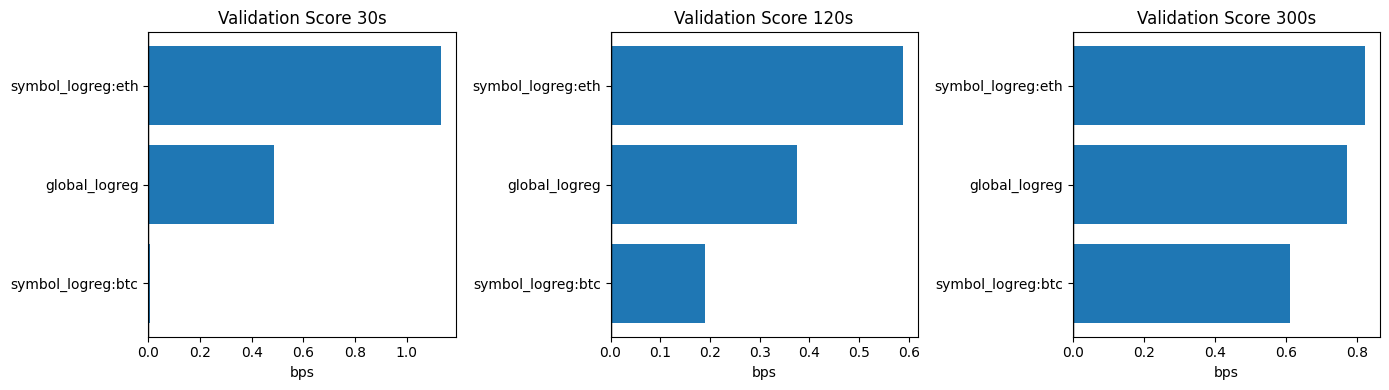

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, h in zip(axes, HORIZONS):
    tmp = val_metrics[val_metrics['horizon_s'] == h].copy()
    tmp['label'] = tmp['model'] + tmp.get('symbol', '').fillna('').map(lambda x: '' if x == '' else ':' + x)
    tmp = tmp.sort_values('Score')
    ax.barh(tmp['label'], tmp['Score'])
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'Validation Score {h}s')
    ax.set_xlabel('bps')
plt.tight_layout()
plt.show()

## Текущая интерпретация

Что смотреть:

- `validation Score`: главное, улучшили ли `PnL_kept` относительно `PnL_all`.
- `PnL_filtered`: желательно отрицательный/хуже kept, значит модель выбрасывает токсичные сделки.
- `filtered_share`: сколько сделок режем.
- `KeptTurnoverPerDay`: constraint должен быть `>= 500k/day`; на sampled режиме turnover масштабируется через `SAMPLE_MOD`.
- coefficients: положительный coef повышает вероятность bad fill.

Дальше можно развивать:

1. обучать отдельные модели `symbol x horizon`;
2. добавить trade-flow фичи по Binance trades;
3. добавить фичи exhaustion/reversal: extreme move before liquidation + spread tightening;
4. перейти с `bad = pnl < 0` на weighted regression / ranking objective по actual PnL;
5. после подключения еще трех месяцев прогнать full mode и зафиксировать пороги.